# Forecasting Revenue

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet

## 1. Load and preparation of time series

In [3]:
df_time_series = pd.read_csv(r"C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\monthly_timeseries.csv")
print('Shape:',df_time_series.shape)
df_time_series.head()

Shape: (24, 3)


,year_month,monthly_revenue,monthly_profit
0,2023-01,4379894.64,974780.12
1,2023-02,2769477.21,619228.38
2,2023-03,3885192.59,867726.10
3,2023-04,4347474.27,958930.58
4,2023-05,4848240.62,1071356.86


In [4]:
df_prophet = pd.DataFrame({
    'ds':pd.to_datetime(df_time_series['year_month']),
    'y':df_time_series['monthly_revenue']
})

print('Dates range:', df_prophet['ds'].min(), df_prophet['ds'].max())
print('Available months:', len(df_prophet))
df_prophet.head()

Dates range: 2023-01-01 00:00:00 2024-12-01 00:00:00
Available months: 24


,ds,y
0,2023-01-01,4379894.64
1,2023-02-01,2769477.21
2,2023-03-01,3885192.59
3,2023-04-01,4347474.27
4,2023-05-01,4848240.62


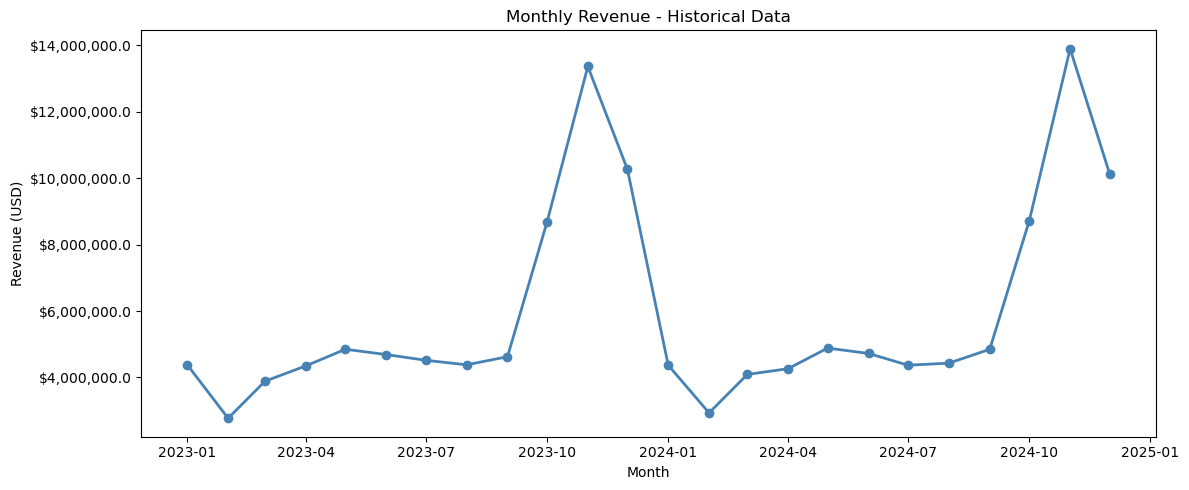

In [5]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_prophet['ds'], df_prophet['y'], marker='o', linewidth=2, color='steelblue')
ax.set_title('Monthly Revenue - Historical Data')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,}'))

plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Monthly Revenue historical data')
plt.show()

## 2. Training model

In [6]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

model.fit(df_prophet)
print('Model Trained')

14:34:24 - cmdstanpy - INFO - Chain [1] start processing
14:34:30 - cmdstanpy - INFO - Chain [1] done processing


Model Trained


## 3. Predictions Q1 2025

In [7]:
future = model.make_future_dataframe(periods=3, freq='MS')
print('Last dates of prediction df:\n',future.tail(5))

Last dates of prediction df:
            ds
22 2024-11-01
23 2024-12-01
24 2025-01-01
25 2025-02-01
26 2025-03-01


In [8]:
forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6)

,ds,yhat,yhat_lower,yhat_upper
21,2024-10-01,8.719542e+06,8.719542e+06,8.719542e+06
22,2024-11-01,1.389967e+07,1.389967e+07,1.389967e+07
23,2024-12-01,1.013437e+07,1.013437e+07,1.013437e+07
24,2025-01-01,4.945252e+06,4.853563e+06,5.042468e+06
25,2025-02-01,3.189595e+06,2.894771e+06,3.502358e+06
26,2025-03-01,4.796613e+06,4.230590e+06,5.353111e+06


In [9]:
q1_2025 = forecast[forecast['ds']>='2025-01-01'][['ds','yhat','yhat_lower','yhat_upper']].copy()
q1_2025.columns = ['month','predicted_revenue','lower_bound','upper_bound']
q1_2025[['predicted_revenue','lower_bound','upper_bound']] = q1_2025[[
    'predicted_revenue','lower_bound','upper_bound']].round(2)

print('Proyection for Q1 2025')
q1_2025

Proyection for Q1 2025


,month,predicted_revenue,lower_bound,upper_bound
24,2025-01-01,4945252.20,4853563.13,5042467.93
25,2025-02-01,3189595.35,2894770.69,3502358.19
26,2025-03-01,4796612.53,4230589.88,5353110.89


## 4. Visualization


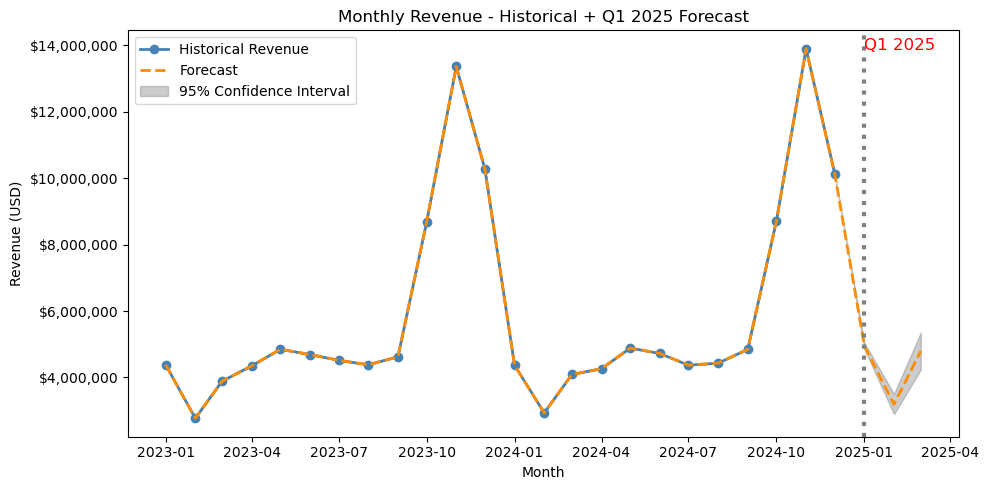

In [10]:
ig, ax = plt.subplots(figsize=(10,5))

#Historical series
ax.plot(df_prophet['ds'], df_prophet['y'],
        marker='o', linewidth=2, color='steelblue', label='Historical Revenue')

#Prediction line
ax.plot(forecast['ds'], forecast['yhat'],
        linewidth=2, linestyle='--', color='darkorange', label='Forecast')

#Confidence interval
ax.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha = 0.4, color='gray', label='95% Confidence Interval'
)

#Vertical line prediction
ax.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle=':', linewidth=3)
ax.text(pd.Timestamp('2025-01-01'), ax.get_ylim()[1] * .96,
        'Q1 2025', color='red',fontsize=12)

ax.set_title('Monthly Revenue - Historical + Q1 2025 Forecast')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\exports\Monthly Revenue Forecasting')
plt.show()

## 5. Trends graphics

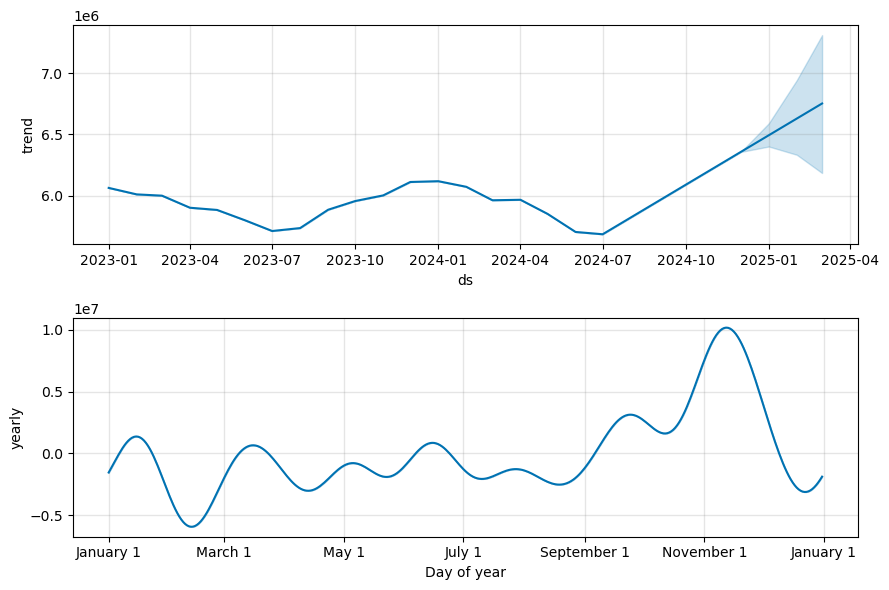

In [11]:
fig_components = model.plot_components(forecast)
plt.show()

## Exports for Power BI

In [14]:
forecast_export = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
forecast_export.columns = ['date','predicted_revenue','lower_bound','upper_bound']
forecast_export['is_forecast'] = forecast_export['date']>='2025-01-01'
forecast_export[['predicted_revenue','lower_bound','upper_bound']] = forecast_export[
    ['predicted_revenue','lower_bound','upper_bound']].round(2)
forecast_export.to_csv(r'C:\Users\kumri\Downloads\Data Science Notebooks\Product Sales\Power_BI exports\forecast_data.csv',
                      index=False)

In [15]:
print(forecast_export[forecast_export['is_forecast']][['date','predicted_revenue','lower_bound','upper_bound']].to_string(index=False))

      date  predicted_revenue  lower_bound  upper_bound
2025-01-01         4945252.20   4853563.13   5042467.93
2025-02-01         3189595.35   2894770.69   3502358.19
2025-03-01         4796612.53   4230589.88   5353110.89
